In [1]:
# 序列数据
# 实际中很多数据是有时序结构的
# 电影的评价随时间的变换而变换
#   - 拿了奖之后评分上升, 直到奖项被忘记
#   - 看了很多好电影后, 人们的期望变高
#   - 季节性: 贺岁片, 暑假档
#   - 导演, 演员的负面报道导致评分变低

# 序列数据 - 更多例子
# 音乐, 语言, 文本, 和视频都是连续的
# 大地震发生后, 很有可能会有几次小的余震
# 人的互动是连续的, 从网上的吵架中可以看出
# 预测明天的股价要比填补昨天遗失的股价更难

# 统计工具
# 在时间t观察到x_t, 那么如果有T个时间, 就有T个不独立的随机变量, (x1, ..., X_T) ~ p(x)
# 联合概率可以用条件概率展开,  p(a,b) = p(a) p(b|a) = p(b) p(a|b)
# p(x) = p(x1) * p(x2|x1) * p(x3|x1, x2) * ... * p(x_T|x1, x2, ..., x_T-1)
# p(x) = p(x_T) * p(x_T-1|x_T) * ... * p(x1|x2, ..., x_T) ->物理上不一定可行
# 这里第二个式子是: 已知未来发生的事情, 往前推前面发生的事情
# 对条件概率建模
# p(x_t|x1,...,x_t-1) = p(x_t|f(x1,...,x_t-1)) -> f(x1,...,x_t-1)是对过去的数据模型建模, 也就是训练一个模型, 也称自回归模型
# 因为这里是给定前面的数据, 去预测下一个数据, 标号和数据是一个东西, 所以叫自回归模型

# 方案A - 马尔可夫假设
# p(x) = p(x1) * p(x2|x1) * p(x3|x1, x2) * ... * p(x_T|x1, x2, ..., x_T-1)
# 在上面这个公式中, 在x_t的事件是与x_t之前的所有事件相关的
# 马尔可夫假设: 假设当前数据只更τ个过去数据点相关
# 也就是 p(x_t|x1,...,x_t-1) = p(x_t|x_t-τ,...,x_t-1) = p(x_t|f(x_t-τ,...,x_t-1))
# 这里的f(x_t-τ,...,x_t-1)例如在过去的数据上训练一个MLP模型

# 方案B - 潜变量模型
# p(x) = p(x1) * p(x2|x1) * p(x3|x1, x2) * ... * p(x_T|x1, x2, ..., x_T-1)
# 在上面这个公式中, 我们引入潜变量h_t来表示过去信息h_t = f(x1,...,x_T-1)
# 这样x_t = p(x_t|h_t)
# 如下:
#  h - h' - h''
#  | / |  / |
#  x - x' - x''
# 表示了h的可迭代性, 并且每个模型只和前面的x和h'相关, 模型简单

# 总结
# 在时序模型中, 当前数据和之前观察到的数据有关
# 自回归模型使用自身过去的数据来预测现在的数据
# 马尔可夫模型假设当前只和最近少数数据有关, 从而简化模型
# 潜变量模型使用潜变量来概括历史信息

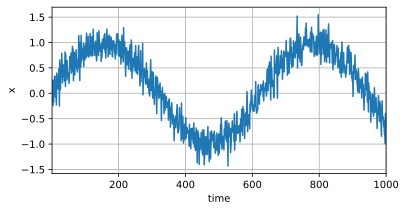

In [6]:
# 序列模型
# 使用sin函数和一些可加性噪音来生成序列数据, 时间步数为1,2,...,1000
%matplotlib inline
import torch
from torch import nn
from d2l import torch as d2l

T = 1000
time = torch.arange(1, T+1, dtype=torch.float32)
x = torch.sin(0.01 * time) + torch.normal(0, 0.2, (T,))
d2l.plot(time, [x], 'time', 'x', xlim=[1,1000], figsize=(6,3))

In [13]:
# 将数据映射为数据对y_t = x_t 和 x=[x_t-τ,...,x_t-1]
# 也就是马尔可夫假设
tau = 4
features = torch.zeros((T - tau, tau)) # features 是一个[996, 4]的vector, 用来存每个时间段前τ个x_t
for i in range(tau):
    features[:, i] = x[i:T - tau + i] # 对996行的每一行填充 [x_t-4, x_t-3, x_t-2, x_t-1]的数据
labels = x[tau:].reshape(-1, 1) # 样本, 也就是从τ到最后

batch_size, n_train = 16, 600
train_iter = d2l.load_array((features[:n_train], labels[:n_train]), batch_size, is_train=True)

In [14]:
# 使用一个相当简单的结构, 只是一个拥有两个全连接层的多层感知机
def init_weights(m):
    if type(m) == nn.Linear:
        nn.init.xavier_uniform_(m.weight)
        
def get_net():
    net = nn.Sequential(nn.Linear(4, 10), nn.ReLU(), nn.Linear(10, 1))
    net.apply(init_weights)
    return net

loss = nn.MSELoss()

In [19]:
def train(net, train_iter, loss, epochs, lr):
    trainer = torch.optim.Adam(net.parameters(), lr)
    for epoch in range(epochs):
        for X, y in train_iter:
            trainer.zero_grad()
            l = loss(net(X), y)
            l.backward()
            trainer.step()
        print(f'epoch {epoch + 1}, '
              f'loss: {d2l.evaluate_loss(net, train_iter, loss):f}')

net = get_net()
train(net, train_iter, loss, 5, 0.01)

epoch 1, loss: 0.071206
epoch 2, loss: 0.056034
epoch 3, loss: 0.050518
epoch 4, loss: 0.049339
epoch 5, loss: 0.047045


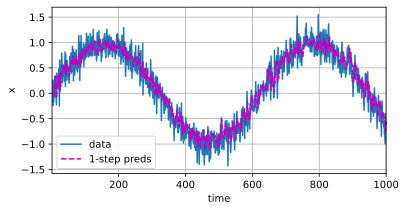

In [21]:
# 模型预测下一个时间步
onestep_preds = net(features)
d2l.plot(
    [time, time[tau:]],
    [x.detach().numpy(), onestep_preds.detach().numpy()], 'time', 'x',
    legend=['data', '1-step preds'], xlim=[1, 1000], figsize=(6,3))

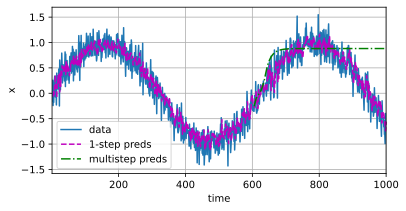

In [27]:
# 进行多步预测
multistep_preds = torch.zeros(T)
multistep_preds[:n_train + tau] = x[:n_train + tau] # 这里是copy了600+tau个features
for i in range(n_train + tau, T):
    multistep_preds[i] = net(multistep_preds[i - tau: i]).reshape(-1, 1) # 这里开始从600+tau预测, 将前tau步加入到net中

d2l.plot([time, time[tau:], time[n_train + tau:]], [
    x.detach().numpy(),
    onestep_preds.detach().numpy(),
    multistep_preds[n_train + tau:].detach().numpy()], 'time', 'x',
         legend=['data', '1-step preds',
                 'multistep preds'], xlim=[1, 1000], figsize=(6, 3))
# 这里的绿线就是多步预测的结果, 很不准, 只有开始的几个点错误不离谱, 因为误差积累变得离谱

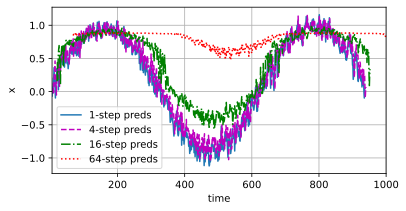

In [46]:
# 仔细的看一下k步预测
max_steps = 64
    
features = torch.zeros((T - tau - max_steps + 1, tau + max_steps)) 
# 初始化一个[933, 68]的特征矩阵，每行代表一次输入实例，包括tau个历史点和max_steps个将要预测的点

for i in range(tau):
    features[:, i] = x[i:i + T - tau - max_steps + 1] # 这里面存了之前tau个的数据

for i in range(tau, tau + max_steps):
    features[:, i] = net(features[:, i - tau:i]).reshape(-1) 
# 对于每一个预测步骤，使用特征矩阵中的最后tau个数据作为输入通过网络net生成下一步的预测，填充至特征矩阵对应列

steps = (1, 4, 16, 64)
d2l.plot([time[tau + i - 1:T - max_steps + i] for i in steps],
         [features[:, (tau + i - 1)].detach().numpy() for i in steps], 'time',
         'x', legend=[f'{i}-step preds'
                      for i in steps], xlim=[5, 1000], figsize=(6, 3))

# 难点是预测很远的未来